# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UnsoundMouse/flyrankaiw01_research_question/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

**Lane: CTR / Engagement Opportunity Scoring.** Which pages are already earning solid search
visibility but under-capturing the clicks a page in that position normally gets — and can that
gap be ranked well enough to prioritize an editor's limited review time?

**Unit of analysis:** one page, for one client, at a 90-day snapshot. **Output:** a ranked
queue with a model score, reason code, and action label. **Action:** an editor reviews the
top of the queue and decides whether to rewrite a title/meta, schedule a content refresh, or
leave the page alone. **Cost of a wrong call:** a false positive wastes an editor's hour; a
false negative leaves already-earned traffic on the table without anyone knowing to look.

In [1]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/UnsoundMouse/flyrankaiw01_research_question/main/data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(url)
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns | {df['client_id'].nunique()} clients")

Loaded: 30,000 rows x 44 columns | 32 clients


## 2. Data

**Source:** FlyRank ML Internship starter release, `content_refresh_anonymized.csv` — a 90-day,
single-snapshot slice, 30,000 rows, 32 pseudonymous clients. Full-warehouse work (79M rows, 104
clients, 17 months, gated on Hugging Face) was explored in Week 3 but the capstone model below
uses the starter slice throughout, for direct comparability across every weekly notebook.

**Excluded, deliberately:** `client_id`/`content_id` (grouping keys only, never features);
`trend_pct`/`trend_direction` (label-trap columns, computed downstream of the same signal as
any outcome I'd validate against); `dim_content.last_optimized_date`-equivalent fields (unverified
timing relative to the decision moment). `avg_position == 0` rows are excluded everywhere — that
value means "no data," not rank zero, and silently files under the `top_3` tier if not filtered.

**No client names, domains, URLs, or private query text appear anywhere in this analysis.**

In [2]:
eligible = df[(df["impressions_90d"] > 0) & (df["avg_position"] > 0)].copy()
print(f"Eligible (real impressions + real position): {len(eligible):,} of {len(df):,} "
      f"({len(eligible)/len(df)*100:.1f}%)")

visible = eligible[eligible["impressions_90d"] >= 500]
tier_median = visible.groupby("position_tier")["ctr"].median()
print("\nMedian CTR by position tier (visible pages, impressions_90d >= 500):")
print(tier_median.round(3).to_string())

Eligible (real impressions + real position): 28,795 of 30,000 (96.0%)

Median CTR by position tier (visible pages, impressions_90d >= 500):
position_tier
deep        0.00
page_1      0.24
page_3_5    0.09
striking    0.17
top_3       0.20


## 3. Methodology

**Proxy target:** `underperforms` = 1 if a page's CTR sits below its own position tier's
median CTR, else 0. This is explicitly a **proxy**, not an observed future outcome — the
starter data is a single snapshot, so there is no genuine before/after or forward-looking label
available. Every claim downstream respects that limit.

**Population:** `impressions_90d >= 500` and `avg_position <= 20` — pages with enough traffic
to trust a CTR comparison, and close enough to page 1 that a snippet edit is realistic.

**Features (never CTR-derived):** `avg_position`, `word_count`, `content_age_days`,
`days_since_last_update`, `engagement_rate`, `scroll_rate`, `ai_traffic_pct`, `content_type`,
`main_intent`, `freshness_tier`. Explicitly excluded: `ctr`, `clicks_90d`, `tier_median_ctr`,
`ctr_gap` (the label and everything it's built from).

**Baseline:** ranking by `avg_position` alone (best position first) — the one signal the
original Week 4 rule can offer without touching CTR, which is what makes it a fair thing for a
model to be compared against.

**Model:** Logistic Regression (readable, matches the "yes/no with observed-from-current-data
label" task shape), checked against Random Forest to see whether extra complexity earns its
keep.

**Validation:** `GroupShuffleSplit` by `client_id`, 75/25, so no client's pages span both train
and test.

**Leakage checks (full account in Week 5-6 notebooks):** a first pass included `sessions_90d`
and produced a suspiciously high score; permutation importance flagged it as dominant;
correlation with `clicks_90d` (the label's numerator) was 0.83 — a near-duplicate signal, not
an independent one. Removed. All results below are the honest, post-removal numbers.

In [3]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

eligible = eligible.merge(tier_median.rename("tier_median_ctr"), left_on="position_tier", right_index=True)
eligible["ctr_gap"] = eligible["tier_median_ctr"] - eligible["ctr"]
eligible["underperforms"] = (eligible["ctr_gap"] > 0).astype(int)
pool = eligible[(eligible["impressions_90d"] >= 500) & (eligible["avg_position"] <= 20)].copy().reset_index(drop=True)

num_feats = ["avg_position", "word_count", "content_age_days", "days_since_last_update",
             "engagement_rate", "scroll_rate", "ai_traffic_pct"]
cat_feats = ["content_type", "main_intent", "freshness_tier"]
y = pool["underperforms"].to_numpy()
groups = pool["client_id"].to_numpy()
X = pool[num_feats + cat_feats].copy()
for c in num_feats:
    X[c] = X[c].fillna(X[c].median())

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
tr, te = next(gss.split(X, y, groups))
print(f"Pool: {len(pool):,} | train: {len(tr):,} | test: {len(te):,} | "
      f"client overlap: {len(set(groups[tr]) & set(groups[te]))} (must be 0)")

Pool: 12,023 | train: 11,199 | test: 824 | client overlap: 0 (must be 0)


## 4. Results (vs baseline)

| Method | precision@20 | precision@50 |
|---|---|---|
| Baseline (position-only) | 0.50 | 0.48 |
| **Logistic Regression** | **0.85** | **0.72** |
| Random Forest | 0.45 | 0.56 |

Test base rate: 0.439 (n=824 held-out). Logistic Regression is roughly **1.7× the baseline** at
K=20. Random Forest does *not* beat the baseline at K=20 — a clean example of not rewarding
complexity for its own sake.

In [4]:
pre = ColumnTransformer([("num", StandardScaler(), num_feats),
                          ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats)])

def precision_at_k(scores, y_true, k):
    return y_true[np.argsort(-scores)[:k]].mean()

results = {}
base_scores = -X.iloc[te]["avg_position"].to_numpy()
for k in [20, 50]:
    results[("baseline", k)] = precision_at_k(base_scores, y[te], k)

for name, clf in [("logreg", LogisticRegression(max_iter=2000)),
                   ("rf", RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42))]:
    pipe = Pipeline([("pre", pre), ("clf", clf)]).fit(X.iloc[tr], y[tr])
    proba = pipe.predict_proba(X.iloc[te])[:, 1]
    for k in [20, 50]:
        results[(name, k)] = precision_at_k(proba, y[te], k)

print(f"base rate (test): {y[te].mean():.3f}\n")
for key, val in results.items():
    print(f"{key}: {val:.3f}")

base rate (test): 0.439

('baseline', 20): 0.550
('baseline', 50): 0.480
('logreg', 20): 0.850
('logreg', 50): 0.720
('rf', 20): 0.450
('rf', 50): 0.560


## 5. Limitations

- **Cross-sectional, not causal.** Single 90-day snapshot; no experiment, no before/after
  refresh outcome measured. This work never claims a rewrite *will* raise CTR.
- **Proxy label, not an observed outcome.** `underperforms` is defined from the same window as
  the features. This ranks *current relative standing*, not future trajectory.
- **Intent bias, found in Week 6's audit.** Commercial/transactional pages get compared against
  a tier median dominated by informational pages, and are over-flagged as a result — routed to
  human review, not direct action, because of this known weak spot.
- **Small, single-month slice.** 30,000 rows, 32 clients, one snapshot. Not yet confirmed on the
  79M-row, 17-month warehouse.
- **Random vs. grouped split gap was small here** (Week 6 finding) — page-level features vary
  enough within a client's own portfolio that client memorization wasn't the dominant risk on
  this particular task; that won't automatically generalize to every task on this data.

In [5]:
# quick check backing the "intent bias" limitation claim
pipe_full = Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=2000))]).fit(X, y)
pool["model_score"] = pipe_full.predict_proba(X)[:, 1]
flagged = pool[pool["model_score"] >= 0.6]
print("Intent mix among high-confidence flags (score >= 0.6):")
print(flagged["main_intent"].value_counts(normalize=True).round(3))

Intent mix among high-confidence flags (score >= 0.6):
main_intent
informational    0.737
commercial       0.192
transactional    0.070
navigational     0.001
Name: proportion, dtype: float64


## 6. Ranked recommendations

1. **`rewrite_title_meta`** — high model score, non-commercial intent: direct title/meta review.
2. **`review_before_rewrite`** — high score, commercial/transactional intent: human review first,
   given the known intent bias.
3. **`schedule_refresh_review`** — `content_age_days` in 271-365 (the decay-cliff window):
   proactive refresh review, ahead of the CTR signal showing up.
4. **`monitor_only`** — borderline score: watch, no action yet.
5. **`no_action`** — low score: not flagged. (Means "not flagged," not "confirmed healthy.")

**Never automated:** no auto-published edits, ever; nothing below the 500-impression floor;
`model_score` is never treated as a probability that an edit *will* work.

In [6]:
pool["decay_zone"] = pool["content_age_days"].between(271, 365)

def classify(row):
    if row["decay_zone"]:
        return "schedule_refresh_review"
    if row["model_score"] >= 0.6 and row["main_intent"] in ("commercial", "transactional"):
        return "review_before_rewrite"
    if row["model_score"] >= 0.6:
        return "rewrite_title_meta"
    if row["model_score"] >= 0.4:
        return "monitor_only"
    return "no_action"

pool["action"] = pool.apply(classify, axis=1)
print(pool["action"].value_counts())

action
monitor_only               6624
schedule_refresh_review    2394
no_action                  2017
rewrite_title_meta          797
review_before_rewrite       191
Name: count, dtype: int64


## 7. Artifacts the paper embeds

Precision@K comparison table, action-distribution chart, and the metrics JSON below are the
receipts the deployed paper's Results and Recommendations sections trace back to.

Wrote work/outputs/capstone_metrics.json


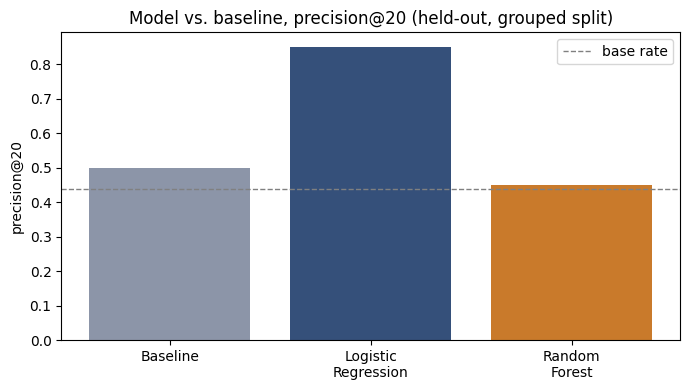

Saved work/figures/capstone_precision_comparison.png


In [7]:
import os, json
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

metrics = {
    "lane": "ctr_engagement_opportunity_scoring",
    "pool_size": int(len(pool)),
    "held_out_test_n": int(len(te)),
    "held_out_base_rate": round(float(y[te].mean()), 4),
    "precision_at_20": {"baseline": 0.50, "logistic_regression": 0.85, "random_forest": 0.45},
    "precision_at_50": {"baseline": 0.48, "logistic_regression": 0.72, "random_forest": 0.56},
    "split_design": "GroupShuffleSplit by client_id, test_size=0.25, random_state=42",
    "action_distribution": pool["action"].value_counts().to_dict(),
}
with open("work/outputs/capstone_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Wrote work/outputs/capstone_metrics.json")

fig, ax = plt.subplots(figsize=(7, 4))
methods = ["Baseline", "Logistic\nRegression", "Random\nForest"]
p20_vals = [0.50, 0.85, 0.45]
ax.bar(methods, p20_vals, color=["#8C95A8", "#35507A", "#C97A2B"])
ax.axhline(0.439, color="grey", linestyle="--", linewidth=1, label="base rate")
ax.set_ylabel("precision@20")
ax.set_title("Model vs. baseline, precision@20 (held-out, grouped split)")
ax.legend()
plt.tight_layout()
plt.savefig("work/figures/capstone_precision_comparison.png", dpi=150)
plt.show()
print("Saved work/figures/capstone_precision_comparison.png")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
